# Lambda Weighting vs Torsional-Diffusion Score Norm

This notebook now benchmarks the **actual live vanilla lambda training path** against the **`TDMdev` torsional-style score-norm path** using the real `ModelKLDM.algorithm2_loss(...)` objective.

It compares:

- vanilla `TrivialisedDiffusion` with paper-style `lambda(t) * MSE`
- `TrivialisedDiffusionDev` with torsional-diffusion-style `score_norm` target normalization
- an empirical inverse-second-moment reference based on the actual simplified target

The goal is to benchmark the current lambda version fairly on:

- actual target scale over time
- objective flattening
- gradient direction and gradient size over time
- short fixed-grid optimization on the live KLDM loss

So this is no longer just a diagnostic picture of curves. It is a small but real head-to-head benchmark of the two training formulations used in this repo.


In [1]:
from __future__ import annotations

import copy
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src/kldm').exists() and (candidate / 'src/kldm/kldm.py').exists():
            return candidate
    raise RuntimeError('Could not find repo root containing src/kldm')


REPO_ROOT = find_repo_root(Path.cwd())
if Path.cwd().name == 'kldm' and Path.cwd().parent.name == 'src':
    os.chdir(REPO_ROOT)

SRC_ROOT = REPO_ROOT / 'src'
bad_package_path = str(SRC_ROOT / 'kldm')
sys.path = [p for p in sys.path if p != bad_package_path]
if 'kldm' in sys.modules:
    mod_file = getattr(sys.modules['kldm'], '__file__', '') or ''
    if mod_file and not mod_file.endswith('__init__.py'):
        del sys.modules['kldm']
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from kldm.data import CSPTask, resolve_data_root
from kldm.diffusionModels.TDMdev import TrivialisedDiffusionDev
from kldm.diffusionModels.trivialized_diffusion import TrivialisedDiffusion
from kldm.scoreNetwork.scoreNetwork import CSPVNet
from kldm.kldm import ModelKLDM

torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'REPO_ROOT={REPO_ROOT}')
print(f'device={device}')
def show_source_lines(path: Path, start: int, end: int) -> None:
    lines = path.read_text().splitlines()
    for lineno in range(start, end + 1):
        print(f"{lineno:4d}: {lines[lineno - 1]}")


MODELS_PROJECT_ROOT: /workspace/.venv/lib/python3.11/site-packages/mattergen
REPO_ROOT=/workspace
device=cpu


In [2]:
root = resolve_data_root()
processed_root = Path(root) / 'mp_20' / 'processed'
download = not processed_root.exists()

task = CSPTask()
train_loader = task.dataloader(
    root=root,
    split='train',
    batch_size=16,
    shuffle=True,
    num_workers=0,
    download=download,
)

benchmark_batches = []
for i, batch_item in enumerate(train_loader):
    benchmark_batches.append(batch_item.to(device))
    if i >= 2:
        break

batch = benchmark_batches[0]

print(f'data_root={root}')
print(f'download={download}')
print(f'benchmark_batches={len(benchmark_batches)}')
print(f'num_graphs(first batch)={batch.num_graphs}')
print(f'num_nodes(first batch)={batch.pos.shape[0]}')
print(f'pos_shape={tuple(batch.pos.shape)} h_shape={tuple(batch.h.shape)} l_shape={tuple(batch.l.shape)}')


data_root=/workspace/data
download=False
benchmark_batches=3
num_graphs(first batch)=16
num_nodes(first batch)=160
pos_shape=(160, 3) h_shape=(160,) l_shape=(16, 6)


In [3]:
tdm = TrivialisedDiffusion(
    eps=1e-3,
    n_lambdas=128,
    lambda_num_batches=8,
).to(device)

tdm_dev = TrivialisedDiffusionDev(
    eps=1e-3,
    n_lambdas=128,
    lambda_num_batches=8,
    n_sigmas=256,
).to(device)

print('precomputing vanilla lambda(t) with live training defaults...')
_ = tdm.precompute_lambda_v_table_from_loader(
    train_loader,
    device=device,
    num_batches=8,
    smooth=True,
    clamp_max=3,
    target_mean_weight=1,
    mean_normalize=True,
)
_ = tdm_dev.precompute_lambda_v_table_from_loader(train_loader, device=device)

print(f'tdm={type(tdm).__name__}')
print(f'tdm_dev={type(tdm_dev).__name__}')
lambda_table = tdm._lambda_v_table.detach()
q = torch.tensor([0.0, 0.1, 0.5, 0.9, 1.0], device=lambda_table.device)
quantiles = torch.quantile(lambda_table, q).tolist()
print('lambda_table_stats',
    f"min={float(lambda_table.min()):.6f}",
    f"mean={float(lambda_table.mean()):.6f}",
    f"max={float(lambda_table.max()):.6f}",
)
print('lambda_table_quantiles', [round(v, 6) for v in quantiles])


TDMdev sigma_norm precompute start n_sigmas=256 k_wn_score=9
TDMdev sigma_norm precompute done seconds=1.2
precomputing vanilla lambda(t) with live training defaults...
tdm=TrivialisedDiffusion
tdm_dev=TrivialisedDiffusionDev
lambda_table_stats min=0.000003 mean=1.000000 max=2.546829
lambda_table_quantiles [3e-06, 3e-06, 0.012964, 2.546829, 2.546829]


## What Torsional Diffusion Actually Does

These are the exact local reference snippets from the `torsional-diffusion` repo in this workspace. They are the target we want to compare against conceptually:

- `utils/training.py`: loss is `((score - pred) ** 2 / score_norm).mean()`
- `diffusion/score_model.py`: network output is multiplied by `sqrt(score_norm)` when `scale_by_sigma=True`

That means `TDMdev` is closer to torsional-diffusion than vanilla `lambda(t)` is, structurally.


In [4]:
training_ref = REPO_ROOT / 'src/torsional/torsional-diffusion-master/utils/training.py'
score_model_ref = REPO_ROOT / 'src/torsional/torsional-diffusion-master/diffusion/score_model.py'
print('torsional-diffusion training loss snippet')
show_source_lines(training_ref, 19, 25)
print('\ntorsional-diffusion output scaling snippet')
show_source_lines(score_model_ref, 157, 160)


torsional-diffusion training loss snippet
  19:         score = torus.score(
  20:             data.edge_rotate.cpu().numpy(),
  21:             data.edge_sigma.cpu().numpy())
  22:         score = torch.tensor(score, device=pred.device)
  23:         score_norm = torus.score_norm(data.edge_sigma.cpu().numpy())
  24:         score_norm = torch.tensor(score_norm, device=pred.device)
  25:         loss = ((score - pred) ** 2 / score_norm).mean()

torsional-diffusion output scaling snippet
 157:         if self.scale_by_sigma:
 158:             score_norm = torus.score_norm(data.edge_sigma.cpu().numpy())
 159:             score_norm = torch.tensor(score_norm, device=data.x.device)
 160:             data.edge_pred = data.edge_pred * torch.sqrt(score_norm)


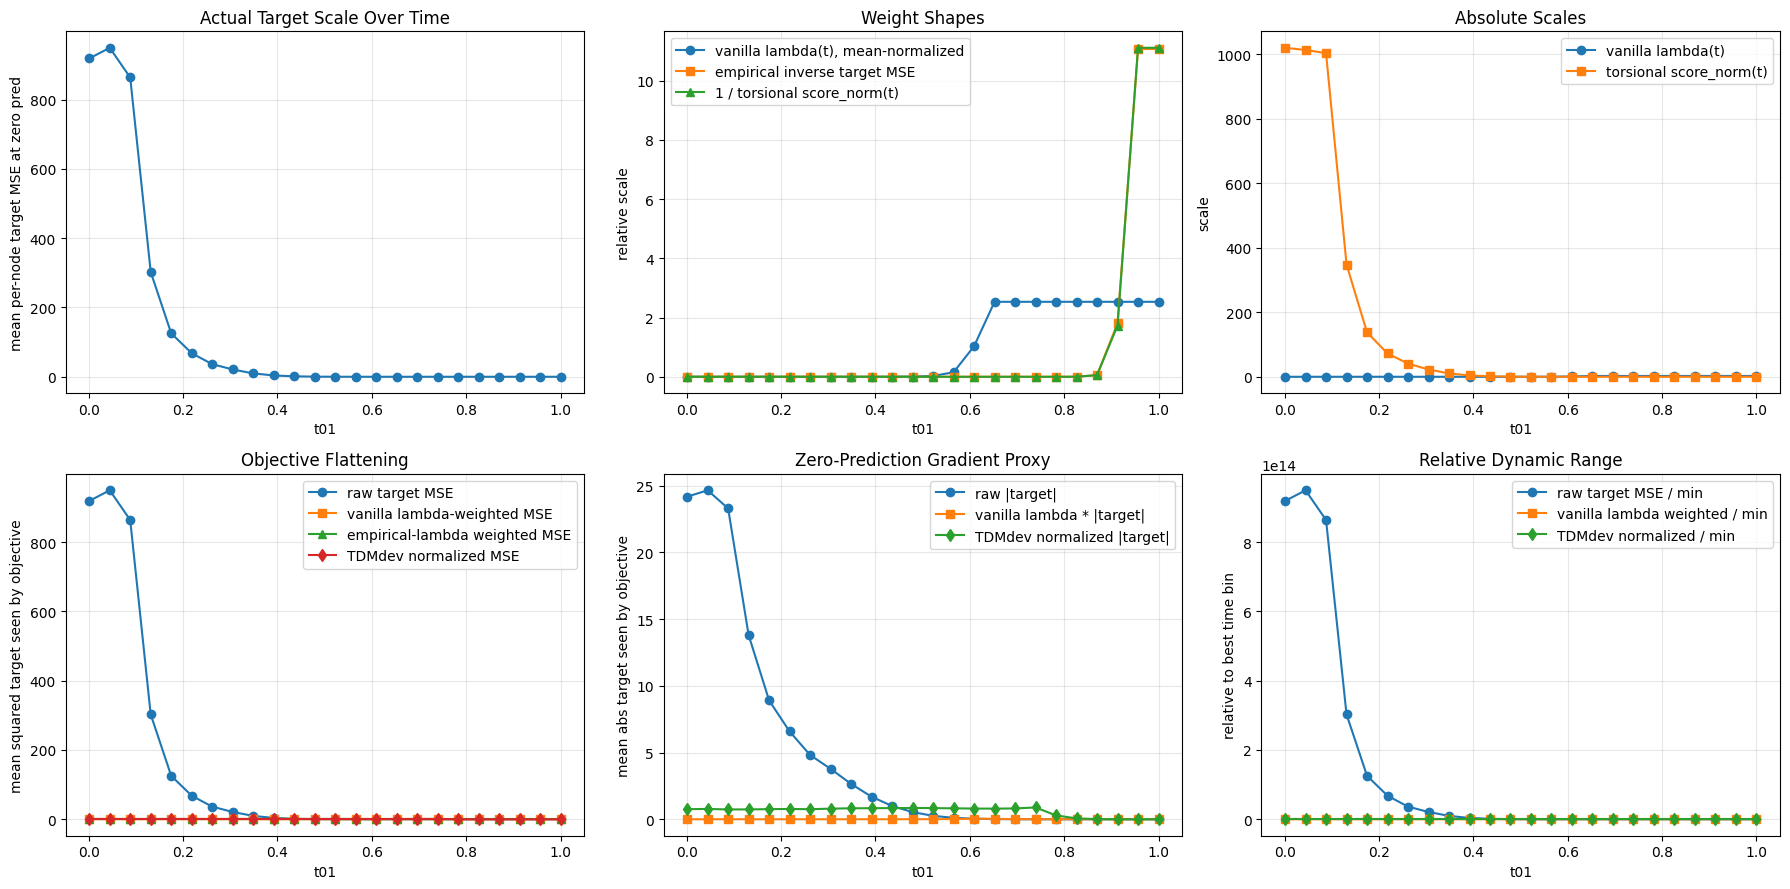

benchmark_flatness_summary
  vanilla_lambda_weighted_zero_pred_mse_cv: 0.7381
  tdmdev_normalized_zero_pred_mse_cv:       0.5648
  empirical_lambda_weighted_zero_pred_mse_cv:0.2769
  vanilla_lambda_weighted_zero_pred_abs_cv: 2.1061
  tdmdev_normalized_zero_pred_abs_cv:       0.5295


In [5]:
@torch.no_grad()
def compare_weighting_curves(batches, tdm, tdm_dev, times, repeats=2):
    curves = {
        'times': [],
        'raw_zero_pred_mse': [],
        'raw_zero_pred_abs': [],
        'sigma_normalized_zero_pred_mse': [],
        'sigma_normalized_zero_pred_abs': [],
        'paper_lambda_t': [],
        'sigma_norm_t': [],
    }

    for t_scalar in times:
        t_value = float(t_scalar)

        raw_zero_pred_mse = 0.0
        raw_zero_pred_abs = 0.0
        sigma_normalized_zero_pred_mse = 0.0
        sigma_normalized_zero_pred_abs = 0.0
        num_evals = 0

        for batch in batches:
            index = batch.batch
            num_nodes = int(batch.pos.shape[0])
            t_graph = torch.full((batch.num_graphs,), t_value, device=batch.pos.device, dtype=batch.pos.dtype)
            t_node = t_graph[index]

            for _ in range(repeats):
                eps_v = torch.randn_like(batch.pos)
                eps_r = torch.randn_like(batch.pos)
                _, v_t, _, _, r_t = tdm.forward_sample(
                    t=t_node,
                    f0=batch.pos,
                    index=index,
                    epsilon_v=eps_v,
                    epsilon_r=eps_r,
                )
                raw_target = tdm.score_target(t=t_node, r_t=r_t, v_t=v_t, index=index)
                sigma_target = tdm_dev.score_target(t=t_node, r_t=r_t, v_t=v_t, index=index)

                raw_target_flat = raw_target.reshape(num_nodes, -1)
                sigma_target_flat = sigma_target.reshape(num_nodes, -1)

                raw_zero_pred_mse += float(raw_target_flat.pow(2).mean(dim=1).mean().item())
                raw_zero_pred_abs += float(raw_target_flat.abs().mean(dim=1).mean().item())
                sigma_normalized_zero_pred_mse += float(sigma_target_flat.pow(2).mean(dim=1).mean().item())
                sigma_normalized_zero_pred_abs += float(sigma_target_flat.abs().mean(dim=1).mean().item())
                num_evals += 1

        raw_zero_pred_mse /= max(num_evals, 1)
        raw_zero_pred_abs /= max(num_evals, 1)
        sigma_normalized_zero_pred_mse /= max(num_evals, 1)
        sigma_normalized_zero_pred_abs /= max(num_evals, 1)

        sigma_norm_t = float(
            tdm_dev._sigma_norm_t(
                torch.tensor([tdm_dev.time_scaling_T * t_value], device=device, dtype=batch.pos.dtype)
            )[0].item()
        )
        paper_lambda_t = float(
            tdm.lambda_v(torch.tensor([t_value], device=device, dtype=batch.pos.dtype))[0].item()
        )

        curves['times'].append(t_value)
        curves['raw_zero_pred_mse'].append(raw_zero_pred_mse)
        curves['raw_zero_pred_abs'].append(raw_zero_pred_abs)
        curves['sigma_normalized_zero_pred_mse'].append(sigma_normalized_zero_pred_mse)
        curves['sigma_normalized_zero_pred_abs'].append(sigma_normalized_zero_pred_abs)
        curves['paper_lambda_t'].append(paper_lambda_t)
        curves['sigma_norm_t'].append(sigma_norm_t)

    return {key: torch.tensor(value, dtype=torch.float32) for key, value in curves.items()}


def coeff_var(x: torch.Tensor) -> float:
    return float((x.std(unbiased=False) / x.mean().clamp_min(1e-12)).item())


times = torch.linspace(1e-3, 1.0, 24)
curves = compare_weighting_curves(batches=benchmark_batches, tdm=tdm, tdm_dev=tdm_dev, times=times, repeats=2)

paper_lambda_norm = curves['paper_lambda_t'] / curves['paper_lambda_t'].mean().clamp_min(1e-12)
empirical_lambda = 1.0 / curves['raw_zero_pred_mse'].clamp_min(1e-12)
empirical_lambda_norm = empirical_lambda / empirical_lambda.mean().clamp_min(1e-12)
sigma_like_lambda = 1.0 / curves['sigma_norm_t'].clamp_min(1e-12)
sigma_like_lambda_norm = sigma_like_lambda / sigma_like_lambda.mean().clamp_min(1e-12)

paper_lambda_weighted_zero_pred_mse = paper_lambda_norm * curves['raw_zero_pred_mse']
empirical_lambda_weighted_zero_pred_mse = empirical_lambda_norm * curves['raw_zero_pred_mse']
paper_lambda_weighted_zero_pred_abs = paper_lambda_norm * curves['raw_zero_pred_abs']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes[0, 0].plot(curves['times'], curves['raw_zero_pred_mse'], marker='o', label='actual simplified target MSE')
axes[0, 0].set_title('Actual Target Scale Over Time')
axes[0, 0].set_xlabel('t01')
axes[0, 0].set_ylabel('mean per-node target MSE at zero pred')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 1].plot(curves['times'], paper_lambda_norm, marker='o', label='vanilla lambda(t), mean-normalized')
axes[0, 1].plot(curves['times'], empirical_lambda_norm, marker='s', label='empirical inverse target MSE')
axes[0, 1].plot(curves['times'], sigma_like_lambda_norm, marker='^', label='1 / torsional score_norm(t)')
axes[0, 1].set_title('Weight Shapes')
axes[0, 1].set_xlabel('t01')
axes[0, 1].set_ylabel('relative scale')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 2].plot(curves['times'], curves['paper_lambda_t'], marker='o', label='vanilla lambda(t)')
axes[0, 2].plot(curves['times'], curves['sigma_norm_t'], marker='s', label='torsional score_norm(t)')
axes[0, 2].set_title('Absolute Scales')
axes[0, 2].set_xlabel('t01')
axes[0, 2].set_ylabel('scale')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)
axes[1, 0].plot(curves['times'], curves['raw_zero_pred_mse'], marker='o', label='raw target MSE')
axes[1, 0].plot(curves['times'], paper_lambda_weighted_zero_pred_mse, marker='s', label='vanilla lambda-weighted MSE')
axes[1, 0].plot(curves['times'], empirical_lambda_weighted_zero_pred_mse, marker='^', label='empirical-lambda weighted MSE')
axes[1, 0].plot(curves['times'], curves['sigma_normalized_zero_pred_mse'], marker='d', label='TDMdev normalized MSE')
axes[1, 0].set_title('Objective Flattening')
axes[1, 0].set_xlabel('t01')
axes[1, 0].set_ylabel('mean squared target seen by objective')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 1].plot(curves['times'], curves['raw_zero_pred_abs'], marker='o', label='raw |target|')
axes[1, 1].plot(curves['times'], paper_lambda_weighted_zero_pred_abs, marker='s', label='vanilla lambda * |target|')
axes[1, 1].plot(curves['times'], curves['sigma_normalized_zero_pred_abs'], marker='d', label='TDMdev normalized |target|')
axes[1, 1].set_title('Zero-Prediction Gradient Proxy')
axes[1, 1].set_xlabel('t01')
axes[1, 1].set_ylabel('mean abs target seen by objective')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 2].plot(curves['times'], curves['raw_zero_pred_mse'] / curves['raw_zero_pred_mse'].min().clamp_min(1e-12), marker='o', label='raw target MSE / min')
axes[1, 2].plot(curves['times'], paper_lambda_weighted_zero_pred_mse / paper_lambda_weighted_zero_pred_mse.min().clamp_min(1e-12), marker='s', label='vanilla lambda weighted / min')
axes[1, 2].plot(curves['times'], curves['sigma_normalized_zero_pred_mse'] / curves['sigma_normalized_zero_pred_mse'].min().clamp_min(1e-12), marker='d', label='TDMdev normalized / min')
axes[1, 2].set_title('Relative Dynamic Range')
axes[1, 2].set_xlabel('t01')
axes[1, 2].set_ylabel('relative to best time bin')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('benchmark_flatness_summary')
print(f"  vanilla_lambda_weighted_zero_pred_mse_cv: {coeff_var(paper_lambda_weighted_zero_pred_mse):.4f}")
print(f"  tdmdev_normalized_zero_pred_mse_cv:       {coeff_var(curves['sigma_normalized_zero_pred_mse']):.4f}")
print(f"  empirical_lambda_weighted_zero_pred_mse_cv:{coeff_var(empirical_lambda_weighted_zero_pred_mse):.4f}")
print(f"  vanilla_lambda_weighted_zero_pred_abs_cv: {coeff_var(paper_lambda_weighted_zero_pred_abs):.4f}")
print(f"  tdmdev_normalized_zero_pred_abs_cv:       {coeff_var(curves['sigma_normalized_zero_pred_abs']):.4f}")


## Reading the Head-to-Head Weighting Benchmark

- This section now averages over multiple real CSP batches, so it is a stronger benchmark of the live vanilla lambda path against `TDMdev`.
- `Objective Flattening` is the main benchmark for whether the vanilla lambda table is doing its job. Lower variation over time is better.
- `Zero-Prediction Gradient Proxy` is the more optimizer-facing view: it tells us whether the immediate update scale is balanced across time.
- The empirical inverse-second-moment curve is not the active training method. It is there as a reference for what a target-matched lambda would look like.


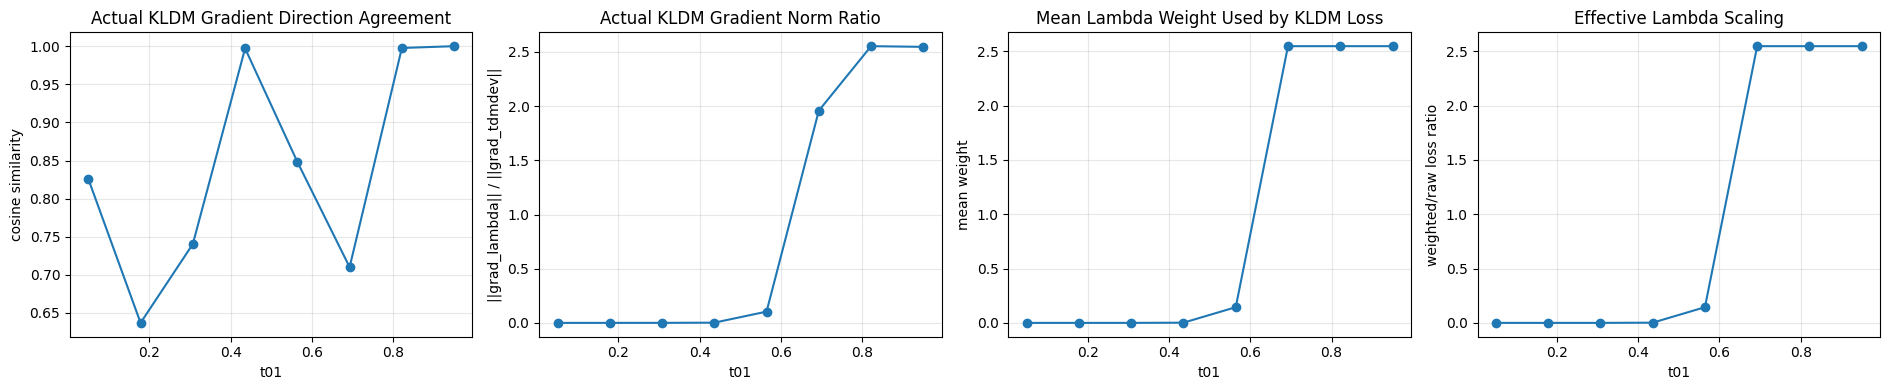

actual_kldm_gradient_summary
  mean_gradient_cosine_similarity=0.844580
  min_gradient_cosine_similarity=0.637025
  mean_gradient_norm_ratio_lambda_over_tdmdev=0.895772
  mean_lambda_effective=0.973357


In [6]:
def build_small_vnet(device: torch.device) -> CSPVNet:
    return CSPVNet(
        hidden_dim=128,
        time_dim=64,
        num_layers=2,
        h_dim=118,
        num_freqs=32,
        ln=True,
        smooth=False,
        pred_h=False,
        pred_v=True,
        pred_l=True,
        zero_cog=True,
    ).to(device)

def build_small_model(tdm_variant, device: torch.device) -> ModelKLDM:
    return ModelKLDM(score_network=build_small_vnet(device), diffusion_v=tdm_variant, device=device).to(device)

def flatten_grads(model: torch.nn.Module) -> torch.Tensor:
    grads = []
    for param in model.score_network.parameters():
        if param.grad is not None:
            grads.append(param.grad.reshape(-1))
    return torch.cat(grads)

def assert_model_has_v_and_l(model, batch):
    batch = batch.to(device)
    t_graph = torch.full((batch.num_graphs, 1), 0.5, device=device, dtype=batch.pos.dtype)
    noisy, _ = model.algorithm1_training_targets(batch=batch, t=t_graph)
    v_t, f_t, l_t = noisy
    preds = model.score_network(
        t=t_graph,
        pos=f_t,
        v=v_t,
        h=batch.h,
        l=l_t,
        node_index=batch.batch,
        edge_node_index=batch.edge_node_index,
    )
    missing = {key for key in ('v', 'l') if key not in preds}
    if missing:
        raise RuntimeError(
            f"Benchmark score network is missing outputs {sorted(missing)}. Rerun the notebook from the top so the updated build_small_vnet(...) definition is active."
        )


def actual_kldm_loss(model, batch, t_graph):
    loss, metrics = model.algorithm2_loss(batch=batch, t=t_graph, lambda_v=1.0, lambda_l=0.0, debug=True)
    return loss, metrics

assert_model_has_v_and_l(build_small_model(copy.deepcopy(tdm), device), benchmark_batches[0])
assert_model_has_v_and_l(build_small_model(copy.deepcopy(tdm_dev), device), benchmark_batches[0])

analysis_times = torch.linspace(0.05, 0.95, 8)
grad_records = {
    't': [],
    'grad_cos': [],
    'grad_norm_ratio': [],
    'lambda_weight_mean': [],
    'lambda_effective': [],
}

for i, t_value in enumerate(analysis_times.tolist()):
    torch.manual_seed(0)
    model_lambda = build_small_model(copy.deepcopy(tdm), device)
    model_sigma = build_small_model(copy.deepcopy(tdm_dev), device)
    model_sigma.score_network.load_state_dict(copy.deepcopy(model_lambda.score_network.state_dict()))

    for model in (model_lambda, model_sigma):
        model.zero_grad(set_to_none=True)

    lambda_losses = []
    sigma_losses = []
    lambda_metrics = []

    for j, batch_eval in enumerate(benchmark_batches):
        t_graph = torch.full((batch_eval.num_graphs, 1), t_value, device=device, dtype=batch_eval.pos.dtype)

        torch.manual_seed(10_000 + i * 100 + j)
        loss_lambda, metrics_lambda = actual_kldm_loss(model_lambda, batch_eval, t_graph)
        torch.manual_seed(10_000 + i * 100 + j)
        loss_sigma, _ = actual_kldm_loss(model_sigma, batch_eval, t_graph)

        lambda_losses.append(loss_lambda)
        sigma_losses.append(loss_sigma)
        lambda_metrics.append(metrics_lambda)

    loss_lambda = torch.stack(lambda_losses).mean()
    loss_sigma = torch.stack(sigma_losses).mean()
    loss_lambda.backward()
    loss_sigma.backward()

    grad_lambda = flatten_grads(model_lambda)
    grad_sigma = flatten_grads(model_sigma)
    grad_cos = F.cosine_similarity(grad_lambda, grad_sigma, dim=0).item()
    grad_norm_ratio = (grad_lambda.norm() / grad_sigma.norm().clamp_min(1e-12)).item()

    lambda_weight_mean = torch.stack([m["lambda_v_mean"] for m in lambda_metrics]).mean().item()
    lambda_effective = torch.stack([m["lambda_v_effective"] for m in lambda_metrics]).mean().item()

    grad_records['t'].append(float(t_value))
    grad_records['grad_cos'].append(float(grad_cos))
    grad_records['grad_norm_ratio'].append(float(grad_norm_ratio))
    grad_records['lambda_weight_mean'].append(float(lambda_weight_mean))
    grad_records['lambda_effective'].append(float(lambda_effective))

grad_records = {key: torch.tensor(value, dtype=torch.float32) for key, value in grad_records.items()}

fig, axes = plt.subplots(1, 4, figsize=(19, 4))
axes[0].plot(grad_records['t'], grad_records['grad_cos'], marker='o')
axes[0].set_title('Actual KLDM Gradient Direction Agreement')
axes[0].set_xlabel('t01')
axes[0].set_ylabel('cosine similarity')
axes[0].grid(True, alpha=0.3)
axes[1].plot(grad_records['t'], grad_records['grad_norm_ratio'], marker='o')
axes[1].set_title('Actual KLDM Gradient Norm Ratio')
axes[1].set_xlabel('t01')
axes[1].set_ylabel('||grad_lambda|| / ||grad_tdmdev||')
axes[1].grid(True, alpha=0.3)
axes[2].plot(grad_records['t'], grad_records['lambda_weight_mean'], marker='o')
axes[2].set_title('Mean Lambda Weight Used by KLDM Loss')
axes[2].set_xlabel('t01')
axes[2].set_ylabel('mean weight')
axes[2].grid(True, alpha=0.3)
axes[3].plot(grad_records['t'], grad_records['lambda_effective'], marker='o')
axes[3].set_title('Effective Lambda Scaling')
axes[3].set_xlabel('t01')
axes[3].set_ylabel('weighted/raw loss ratio')
axes[3].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('actual_kldm_gradient_summary')
print(f"  mean_gradient_cosine_similarity={float(grad_records['grad_cos'].mean()):.6f}")
print(f"  min_gradient_cosine_similarity={float(grad_records['grad_cos'].min()):.6f}")
print(f"  mean_gradient_norm_ratio_lambda_over_tdmdev={float(grad_records['grad_norm_ratio'].mean()):.6f}")
print(f"  mean_lambda_effective={float(grad_records['lambda_effective'].mean()):.6f}")


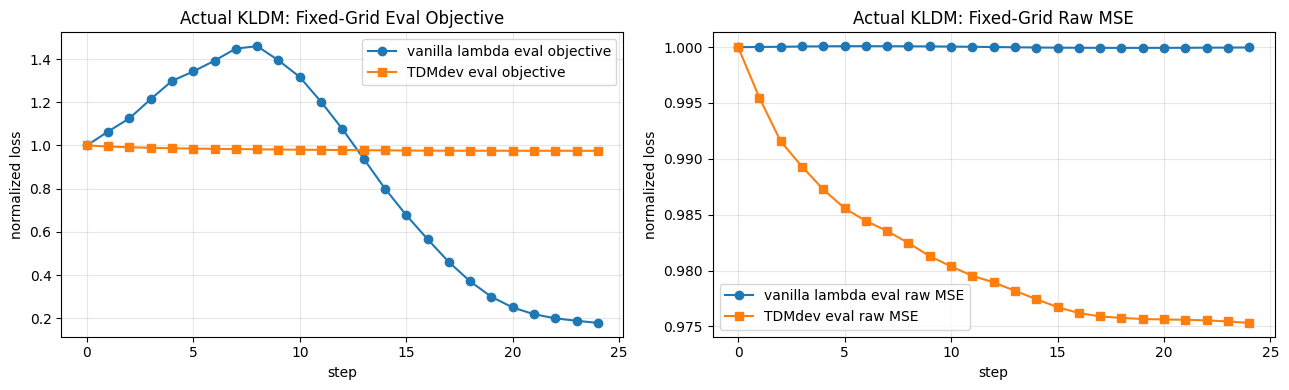

actual_kldm_paired_optimization_summary
  vanilla_lambda_eval_objective_improvement: 82.1086%
  tdmdev_eval_objective_improvement:         2.4688%
  vanilla_lambda_eval_raw_mse_improvement:   0.0032%
  tdmdev_eval_raw_mse_improvement:           2.4688%


In [7]:
steps = 24
lr = 2e-4
eval_times = torch.linspace(0.05, 0.95, 8)

def evaluate_models_over_grid(model, batches, eval_times):
    model.eval()
    objective_vals = []
    raw_vals = []
    for j, t_value in enumerate(eval_times.tolist()):
        batch_objectives = []
        batch_raws = []
        for k, batch_eval in enumerate(batches):
            t_graph = torch.full((batch_eval.num_graphs, 1), t_value, device=device, dtype=batch_eval.pos.dtype)
            torch.manual_seed(30_000 + j * 100 + k)
            _, metrics = model.algorithm2_loss(batch=batch_eval, t=t_graph, lambda_v=1.0, lambda_l=0.0, debug=True)
            batch_objectives.append(float(metrics["loss_v"].item()))
            batch_raws.append(float(metrics["raw_loss_v"].item()))
        objective_vals.append(sum(batch_objectives) / len(batch_objectives))
        raw_vals.append(sum(batch_raws) / len(batch_raws))
    model.train()
    return float(torch.tensor(objective_vals).mean().item()), float(torch.tensor(raw_vals).mean().item())

torch.manual_seed(0)
model_lambda = build_small_model(copy.deepcopy(tdm), device)
model_tdmdev = build_small_model(copy.deepcopy(tdm_dev), device)
model_tdmdev.score_network.load_state_dict(copy.deepcopy(model_lambda.score_network.state_dict()))
opt_lambda = torch.optim.Adam(model_lambda.score_network.parameters(), lr=lr)
opt_tdmdev = torch.optim.Adam(model_tdmdev.score_network.parameters(), lr=lr)

train_schedule = []
for step in range(steps):
    t_value = float(0.05 + 0.90 * step / max(steps - 1, 1))
    batch_idx = step % len(benchmark_batches)
    train_schedule.append((benchmark_batches[batch_idx], t_value, 40_000 + step))

history = {
    'step': [],
    'lambda_eval_objective': [],
    'tdmdev_eval_objective': [],
    'lambda_eval_raw': [],
    'tdmdev_eval_raw': [],
}

initial_lambda_eval, initial_lambda_raw = evaluate_models_over_grid(model_lambda, benchmark_batches, eval_times)
initial_tdmdev_eval, initial_tdmdev_raw = evaluate_models_over_grid(model_tdmdev, benchmark_batches, eval_times)
history['step'].append(0)
history['lambda_eval_objective'].append(initial_lambda_eval)
history['tdmdev_eval_objective'].append(initial_tdmdev_eval)
history['lambda_eval_raw'].append(initial_lambda_raw)
history['tdmdev_eval_raw'].append(initial_tdmdev_raw)

for step, (batch_train, t_value, seed) in enumerate(train_schedule, start=1):
    t_graph = torch.full((batch_train.num_graphs, 1), t_value, device=device, dtype=batch_train.pos.dtype)

    opt_lambda.zero_grad(set_to_none=True)
    torch.manual_seed(seed)
    loss_lambda, _ = model_lambda.algorithm2_loss(batch=batch_train, t=t_graph, lambda_v=1.0, lambda_l=0.0, debug=False)
    loss_lambda.backward()
    opt_lambda.step()

    opt_tdmdev.zero_grad(set_to_none=True)
    torch.manual_seed(seed)
    loss_tdmdev, _ = model_tdmdev.algorithm2_loss(batch=batch_train, t=t_graph, lambda_v=1.0, lambda_l=0.0, debug=False)
    loss_tdmdev.backward()
    opt_tdmdev.step()

    lambda_eval, lambda_raw = evaluate_models_over_grid(model_lambda, benchmark_batches, eval_times)
    tdmdev_eval, tdmdev_raw = evaluate_models_over_grid(model_tdmdev, benchmark_batches, eval_times)

    history['step'].append(step)
    history['lambda_eval_objective'].append(lambda_eval)
    history['tdmdev_eval_objective'].append(tdmdev_eval)
    history['lambda_eval_raw'].append(lambda_raw)
    history['tdmdev_eval_raw'].append(tdmdev_raw)

history = {key: torch.tensor(value, dtype=torch.float32) for key, value in history.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['step'], history['lambda_eval_objective'] / history['lambda_eval_objective'][0], marker='o', label='vanilla lambda eval objective')
axes[0].plot(history['step'], history['tdmdev_eval_objective'] / history['tdmdev_eval_objective'][0], marker='s', label='TDMdev eval objective')
axes[0].set_title('Actual KLDM: Fixed-Grid Eval Objective')
axes[0].set_xlabel('step')
axes[0].set_ylabel('normalized loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history['step'], history['lambda_eval_raw'] / history['lambda_eval_raw'][0], marker='o', label='vanilla lambda eval raw MSE')
axes[1].plot(history['step'], history['tdmdev_eval_raw'] / history['tdmdev_eval_raw'][0], marker='s', label='TDMdev eval raw MSE')
axes[1].set_title('Actual KLDM: Fixed-Grid Raw MSE')
axes[1].set_xlabel('step')
axes[1].set_ylabel('normalized loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
lambda_improvement = 1.0 - float(history['lambda_eval_objective'][-1] / history['lambda_eval_objective'][0])
tdmdev_improvement = 1.0 - float(history['tdmdev_eval_objective'][-1] / history['tdmdev_eval_objective'][0])
lambda_raw_improvement = 1.0 - float(history['lambda_eval_raw'][-1] / history['lambda_eval_raw'][0])
tdmdev_raw_improvement = 1.0 - float(history['tdmdev_eval_raw'][-1] / history['tdmdev_eval_raw'][0])
print('actual_kldm_paired_optimization_summary')
print(f'  vanilla_lambda_eval_objective_improvement: {lambda_improvement:.4%}')
print(f'  tdmdev_eval_objective_improvement:         {tdmdev_improvement:.4%}')
print(f'  vanilla_lambda_eval_raw_mse_improvement:   {lambda_raw_improvement:.4%}')
print(f'  tdmdev_eval_raw_mse_improvement:           {tdmdev_raw_improvement:.4%}')


## How to Read the Actual Benchmark

- The weighting plots compare the current vanilla lambda table against both the torsional-style `score_norm` path and an empirical target-matched reference.
- The gradient section now uses the actual `ModelKLDM.algorithm2_loss(...)` path with `lambda_l=0`, so it benchmarks the real velocity training objective instead of a lighter proxy.
- The short optimization section also uses the actual KLDM loss on multiple real CSP batches and a fixed evaluation grid.
- If vanilla lambda improves its fixed-grid objective and raw MSE similarly to `TDMdev`, that is real evidence it is competitive. If not, the difference is no longer just plotting or notation; it is in the actual training objective.
